<a href="https://colab.research.google.com/github/Vieiraligia/Data-Science-and-Analytics/blob/main/MVP%20Analise%20de%20Dados%20e%20Boas%20Praticas/MVP_AnalisedeDadoseBoasPraticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Análise de Dados e Boas Práticas

**Autora:** Ligia R. Vieira  

**Matrícula:** 1200158

**Data:** Março/2026


**Dataset:** [ Students Performance](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?resource=download)

# Definição do Problema

O objetivo deste projeto é analisar os fatores que influenciam o desempenho acadêmico de estudantes nos exames, tendo como base de referência o Dataset <i>**Students Performance in Exams**</i>.

O dataset é composto por informações demográficas, sociais e educacionais dos estudantes, além de notas em matemática, leitura e escrita.

A análise busca compreender padrões e relações entre as variáveis, com o objetivo de identificar quais fatores podem impactar de forma positiva ou negativa o desempenho dos alunos.

Para isso, a composição da análise será realizada por meio de estatísticas descritivas, visualizações e técnicas de pré-processamento de dados.
<br><br>
## Hipóteses do Problema

1. Estudantes que realizaram curso preparatório tendem a apresentar melhores notas.
2. Existe diferença de desempenho entre estudantes do sexo masculino e feminino.
3. Fatores demográficos e sociais podem evidenciar algum tipo de desigualdade no desempenho acadêmico.
4. Existe alguma correlação entre as notas de leitura e escrita.
5. As notas de matemática apresentam maior variabilidade, indicando maior dispersão dos resultados em relação às disciplinas de leitura e escrita.
<br>

## Tipo do Problema

Este é um problema de aprendizado supervisionado de regressão, porque envolve possível previsão de valores numéricos relacionados ao desempenho dos estudantes, como as notas em matemática, leitura e escrita.
<br><br>
## Seleção de Dados

O Dataset escolhido foi obtido no repositório Kaggle, sendo um conjunto de dados público e previamente estruturado.
Dessa forma, o foco do trabalho concentra-se na análise exploratória e no pré-processamento dos dados.
<br><br>
## Atributos do Dataset


O conjunto de dados é composto por variáveis categóricas relacionadas a informações demográficas e socioeconômicas, gênero, grupo étnico, tipo de alimentação escolar, escolaridade dos pais e participação em curso preparatório. Além disso, contém variáveis numéricas correspondentes às notas obtidas nas disciplinas de matemática, leitura e escrita. O conjunto reúne 8 atributos.

Atributos categórico:
- gender
- race/ethnicity
- parental level of education
- lunch
- test preparation course

Atributos numérico:
- math score
- reading score
- writing score



## Importação das Bibliotecas Necessárias e Carga de Dados
Para a realização do trabalho, foram utilizadas bibliotecas mais utilizadas na área de Ciência de Dados como: Pandas, NumPy, Matplotlib, Seaborn e Scikit-learn.

In [347]:
# Imports necessários

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML


# teste
from sklearn.model_selection import train_test_split



In [348]:
# dataset pelo meu github (raw)
url = "https://raw.githubusercontent.com/Vieiraligia/Data-Science-and-Analytics/main/MVP%20Analise%20de%20Dados%20e%20Boas%20Praticas/StudentsPerformance.csv"


df = pd.read_csv(url)



In [349]:
display(HTML("<h3 style='text-align:center;'>Primeiras 15 linhas do Dataset</h3>"))
df.head(15)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


# Análise de Dados - EDA


A realização da Análise de Dados Exploratória (EDA) tem como objetivo compreender as informações disponíveis no Dataset<b> *Students Performance in Exams*</b>, aplicando:

As análises descritivas e estatísticas:
- Quantidade de atributos e instâncias presentes no dataset;
- Identificação dos tipos de dados de cada atributo;
- Análise das primeiras linhas do conjunto de dados, buscando identificar padrões iniciais ou possíveis inconsistências;
- Verificação da existência de valores nulos, outliers ou dados inconsistentes;
- Cálculo de estatísticas descritivas dos atributos numéricos, como mínimo, máximo, média, mediana, desvio-padrão, quartis e moda.
<br>

A visualização de dados:

- Análise da distribuição dos atributos por meio de histogramas e gráficos de contagem;
- Avaliação da relação entre variáveis por meio de boxplots;
- Análise da correlação entre variáveis numéricas por meio de matriz de correlação.

Além do objetivo de compreender os dados, a análise estatística e a visualização são orientadas para a validação das hipóteses levantadas.

### Total e Tipo das Instâncias


Como mencionado anteriormente, esse conjunto de dados é composto por 8 atributos de variáveis categóricas, representadas pelo tipo <b><i>object </b></i> e variáveis numéricas, representadas pelo tipo <b><i>int64</b></i>. Observa-se que não há valores faltantes, pois todos os atributos retornam 1000 registros para cada atributo.



In [350]:
print("Total de instâncias:", len(df))
print("Total de atributos:", len(df.columns))
print("Tipos de dados: \n")

print(df.info())


Total de instâncias: 1000
Total de atributos: 8
Tipos de dados: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


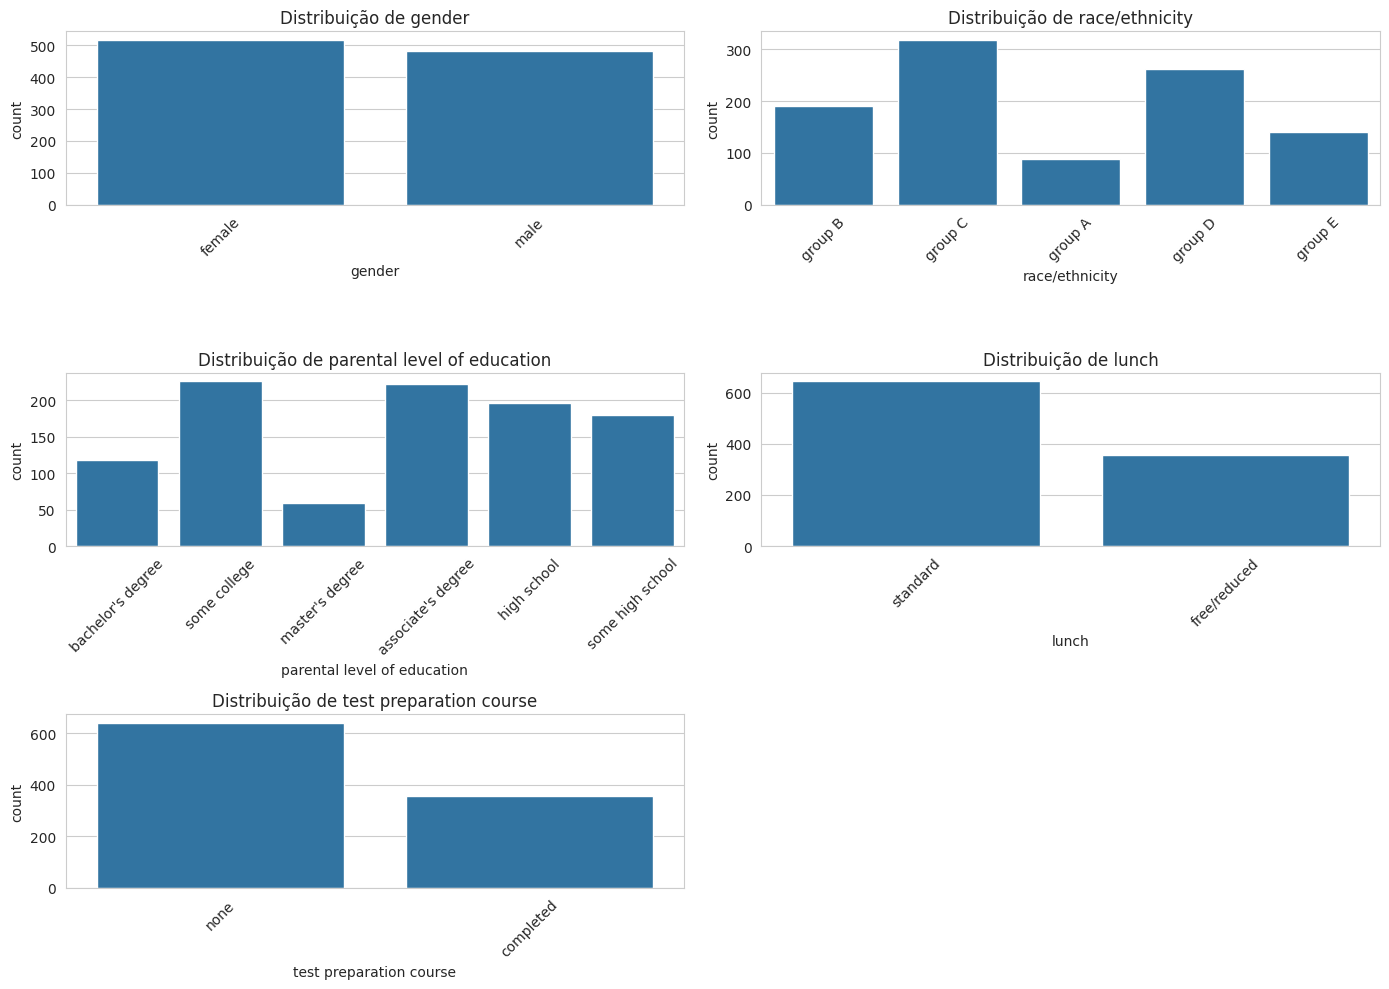

In [ ]:
# visual. geral das variaveis categ.

colunas_categoricas = df.select_dtypes(include="object").columns

plt.figure(figsize=(14,10))

for i, col in enumerate(colunas_categoricas, 1):
    plt.subplot(3,2,i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distribuição de {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

A análise da distribuição das classes de variáveis categóricas indica que, de modo geral, a distribuição é relativamente  equilibrada, enquanto outras possuem menor representação.





## Estatísticas Descritivas

In [351]:
# gerando as principais estatisticas

display(HTML("<h3 style='text-align:center;'>Estatísticas Descritivas</h3>"))
descriptive_statistics = pd.concat([
    df.describe()[['math score',
                   'reading score',
                   'writing score']].round(2).T,

    df[['math score',
        'reading score',
        'writing score']].mode().round(2).T
],
axis=1).rename(columns={
    'count': 'Contagem',
    'std': 'Desvio Padrão',
    'mean': 'Média',
    'min': 'Mínimo',
    'max': 'Máximo',
    '25%': '1º Quartil',
    '50%': 'Mediana',
    '75%': '3º Quartil',
    0: 'Moda'
})
descriptive_statistics

,Contagem,Média,Desvio Padrão,Mínimo,1º Quartil,Mediana,3º Quartil,Máximo,Moda
math score,1000.0,66.09,15.16,0.0,57.00,66.0,77.0,100.0,65
reading score,1000.0,69.17,14.60,17.0,59.00,70.0,79.0,100.0,72
writing score,1000.0,68.05,15.20,10.0,57.75,69.0,79.0,100.0,74


Dentro da Estatística Descritiva, existem medidas que auxiliam na interpretação e no resumo dos dados. Entre essas medidas, destacam-se as de tendência central e de dispersão, que foram aplicadas às notas obtidas nas disciplinas de matemática, leitura e escrita.

Ao analisar as médias, observa-se que os estudantes apresentam desempenho médio de aproximadamente 66,09 em matemática, 69,17 em leitura e 68,05 em escrita. Em comparação com matemática, as disciplinas de leitura e escrita apresentam desempenho médio discretamente superior.

A análise do desvio padrão indica uma variabilidade moderada nas notas. Isso sugere que o desempenho dos estudantes apresenta certa dispersão em relação à média, evidenciando diferenças no desempenho entre os alunos.

A análise dos valores mínimos e máximos indica uma amplitude nas notas. Em matemática há registros que variam de 0 a 100.0 que evidencia desempenhos tanto no limite mínimo quanto no máximo da escala. Nas disciplinas de leitura e escrita observa-se comportamento semelhante, porém com valores mínimos levemente superiores.

A análise dos quartis permite identificar a faixa em que se concentra a maior parte das observações. Em matemática, 50% das notas estão aproximadamente entre 57 e 77 pontos. De maneira semelhante, nas disciplinas de leitura e escrita, a maior parte das notas também se encontra em intervalos próximos dessa faixa, com isso, o desempenho predominante dos estudantes encontra-se em nível intermediário.


## Visualização

### Histograma e KDE

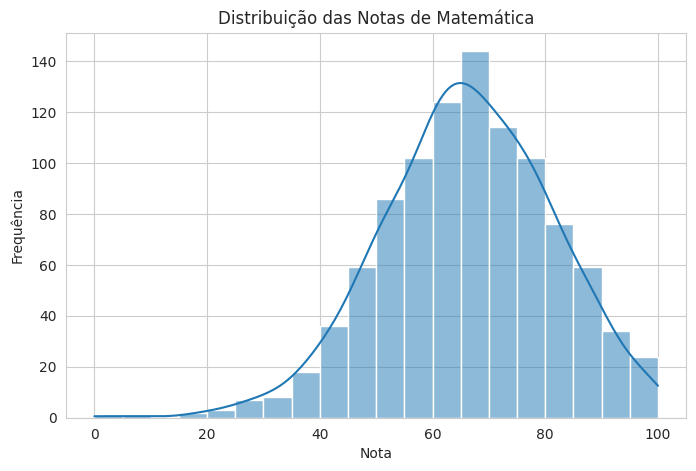

In [352]:
# distribuicao de nota e densidade mat.


sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.histplot(df["math score"], bins=20, kde=True)

plt.title("Distribuição das Notas de Matemática")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

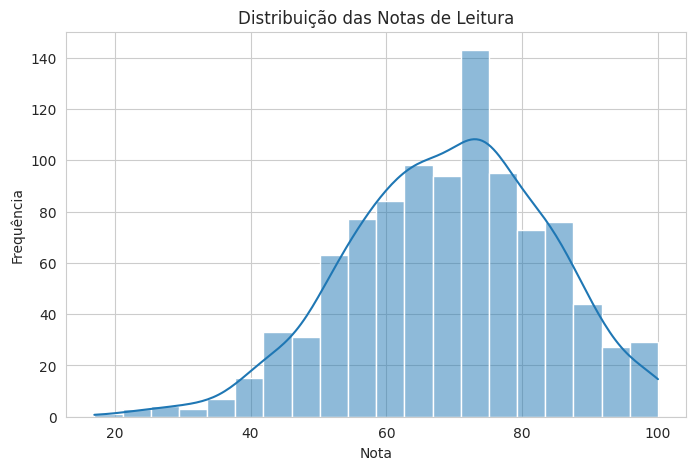

In [ ]:
# distribuicao de nota e densidade leit.

plt.figure(figsize=(8,5))

sns.histplot(df["reading score"], bins=20, kde=True)

plt.title("Distribuição das Notas de Leitura")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

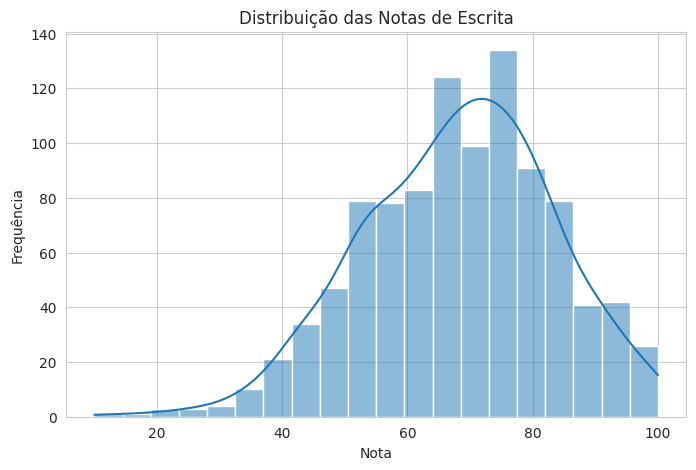

In [ ]:
# distribuicao de nota e densidade escr.

plt.figure(figsize=(8,5))

sns.histplot(df["writing score"], bins=20, kde=True)

plt.title("Distribuição das Notas de Escrita")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

As distribuições das notas nas disciplinas parecem apresentar formato semelhante, onde a maior frequência de observações se concentra em torno das notas centrais, entre 60 e 80 pontos.

### Boxplot

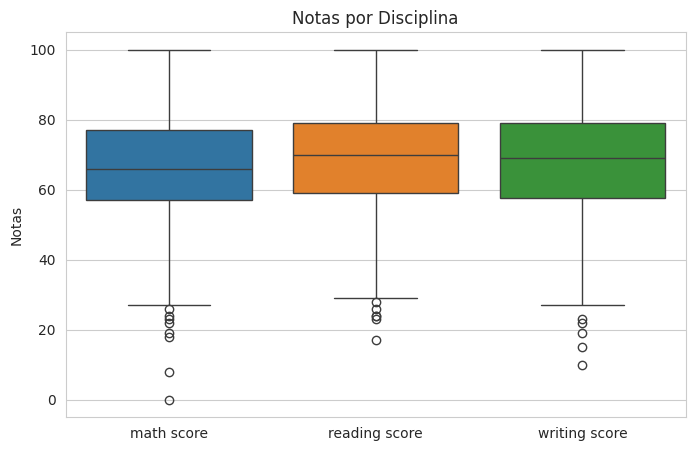

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.boxplot(data=df[[
    "math score",
    "reading score",
    "writing score"
]])

plt.title("Notas por Disciplina")
plt.ylabel("Notas")


plt.show()

In [353]:
# qtd de todos outliers por coluna
# ainda sim esta dentro da escala

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

outliers_dict = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outliers_dict[col] = outliers


for col, out in outliers_dict.items():
    print(f"{col}: {len(out)} outliers")

math score: 8 outliers
reading score: 6 outliers
writing score: 5 outliers


Ainda no contexto de análise de distribuição e da dispersão dos dados, o gráfico do tipo Boxplot tem uma função complementar de análise.

As percepções visuais identificam uma certa dispersão na disciplina de matemática, sugerindo uma possível presença de outlier ou, de fato, um valor real referente às notas de estudantes. Para aprofundar a análise, foi utilizada a técnica de detecção de outliers baseada no método IQR (Interquartile Range) para todas as variáveis numéricas.



### Matriz de Correlação

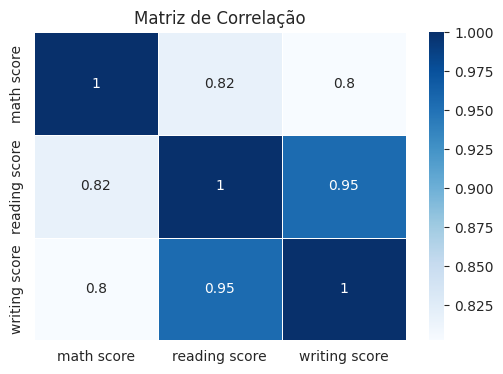

In [354]:

corr = df[["math score","reading score","writing score"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.show()

A análise do grau de relação linear entre as notas das disciplinas aponta um indício inicial para a validação de uma das hipóteses.

Observa-se uma forte correlação positiva entre leitura e escrita, ou seja, estudantes com melhor desempenho em leitura tendem também a apresentar melhores resultados em escrita. Por outro lado, as correlações envolvendo a disciplina de matemática mostram uma relação menos intensa com as demais.

## Verificação de Valores Nulos e Duplicados

In [ ]:
display(HTML("<h3 style='text-align:center;'>Verificação dos Dados</h3>"))

display(HTML("<h4>Valores Nulos</h4>"))
display(df.isna().sum())

display(HTML("<h4>Registros Duplicados:</h4>"))
display(df.duplicated().sum())

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


np.int64(0)

A verificação realizada indica que não há valores ausentes em nenhum dos atributos e também não foram identificadas instâncias duplicadas no conjunto de dados.

Dessa forma, os dados apresentam boa qualidade inicial para as etapas de análise exploratória e pré-processamento.

## Exploração Adicional dos Dados

Seção adicional voltada à visualização, ao aprofundamento da análise e à exploração do conjunto de dados, na busca de padrões e relações entre as diferentes variáveis.

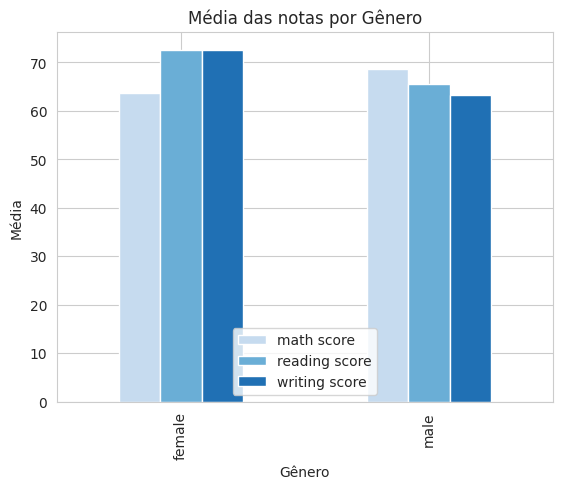

In [ ]:
# média de nota por sexo
 # ajuda na hipotese 2


cores = sns.color_palette("Blues", 3)

df.groupby('gender')[['math score','reading score','writing score']]\
  .mean()\
  .plot(kind='bar', color=cores)

plt.title('Média das notas por Gênero')
plt.ylabel('Média')
plt.xlabel('Gênero')

plt.show()

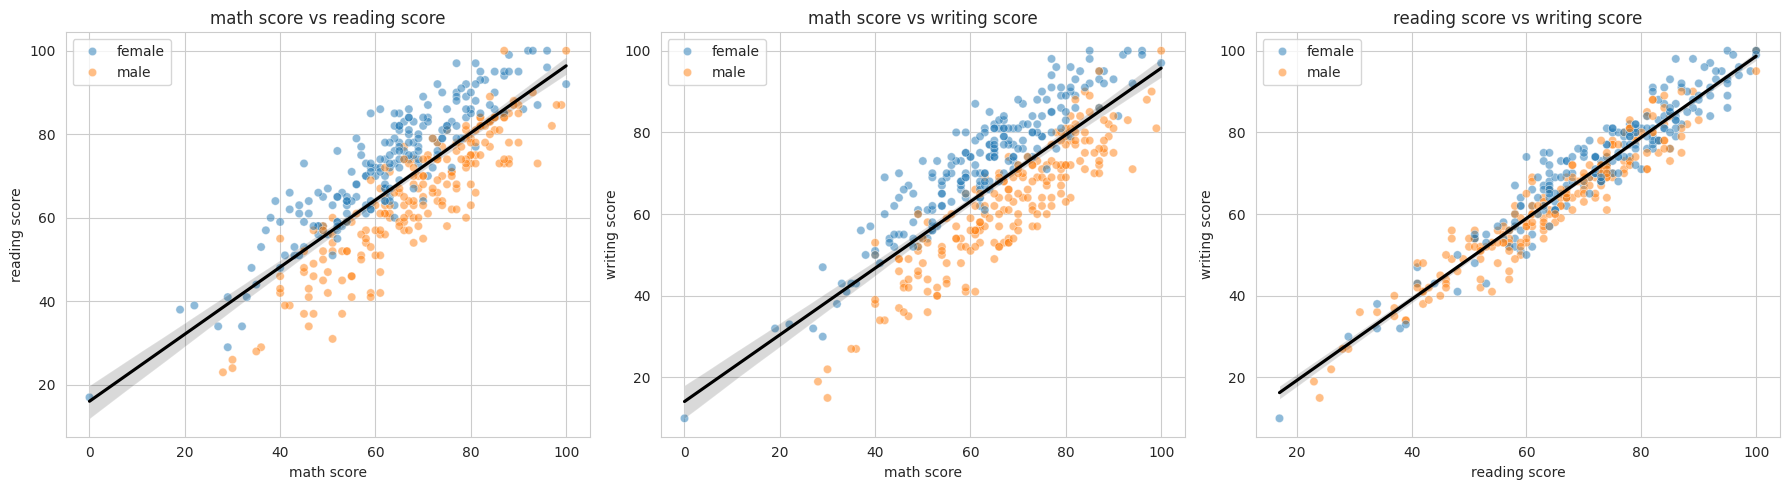

In [ ]:
# relacao entre disciplinas e diferença entre genero

df_sample = df.sample(400, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

pairs = [
    ("math score", "reading score"),
    ("math score", "writing score"),
    ("reading score", "writing score")
]

for i, (x, y) in enumerate(pairs):

    sns.scatterplot(
        data=df_sample,
        x=x,
        y=y,
        hue="gender",
        alpha=0.5,
        ax=axes[i]
    )

    sns.regplot(
        data=df_sample,
        x=x,
        y=y,
        scatter=False,
        ax=axes[i],
        color="black"
    )

    axes[i].set_title(f"{x} vs {y}")
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].legend()

plt.tight_layout()
plt.show()

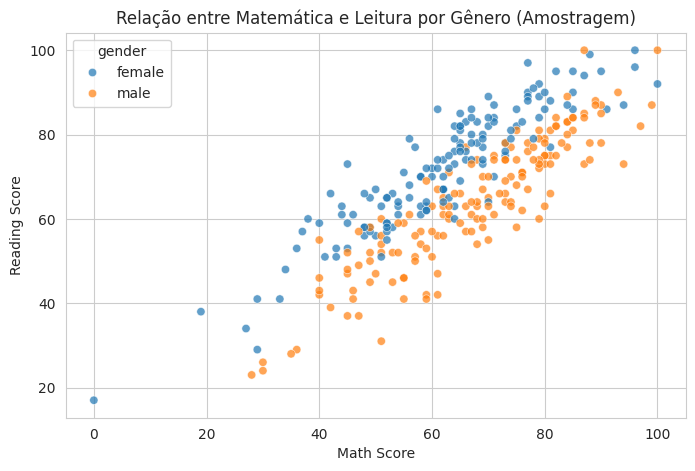

In [ ]:
# amostragem rel. matematica e leitura X genero
df_sample = df.sample(300, random_state=42)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_sample,
    x="math score",
    y="reading score",
    hue="gender",
    alpha=0.7
)

plt.title("Relação entre Matemática e Leitura por Gênero (Amostragem)")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.show()

<Axes: xlabel='race/ethnicity', ylabel='Nota Média'>

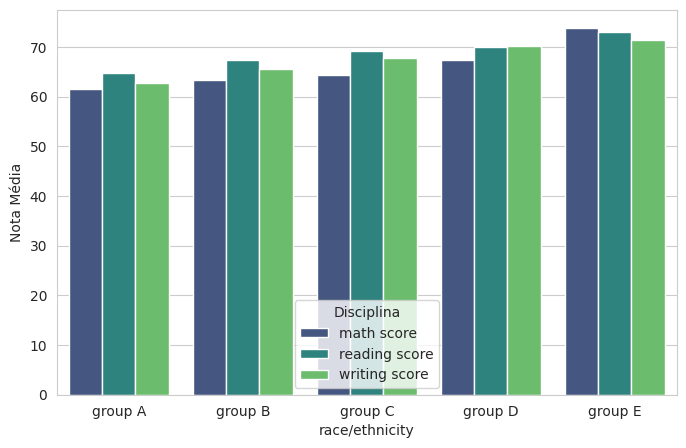

In [ ]:
# de fato o grupo étnico x média de nota revela alguma desigualdade?

media_raca = df.groupby('race/ethnicity')[[
    'math score',
    'reading score',
    'writing score'
]].mean().reset_index()

media_raca_melt = media_raca.melt(
    id_vars='race/ethnicity',
    var_name='Disciplina',
    value_name='Nota Média'
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=media_raca_melt,
    x='race/ethnicity',
    y='Nota Média',
    hue='Disciplina',
    palette='viridis'
)

In [ ]:
# é verdade que esse indicador socioeconomico tem relacao no desempenho academico?

df.groupby("lunch")[[
    "math score",
    "reading score",
    "writing score"
]].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [ ]:
#H1
df.groupby("test preparation course")[[
    "math score",
    "reading score",
    "writing score"
]].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [ ]:
#H3

variaveis_sociais = [
    "lunch",
    "race/ethnicity",
    "parental level of education"
]

for var in variaveis_sociais:
    print(f"\n Análise por {var}")

    display(
        df.groupby(var)[[
            "math score",
            "reading score",
            "writing score"
        ]].mean()
    )


 Análise por lunch


,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256



 Análise por race/ethnicity


,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143



 Análise por parental level of education


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


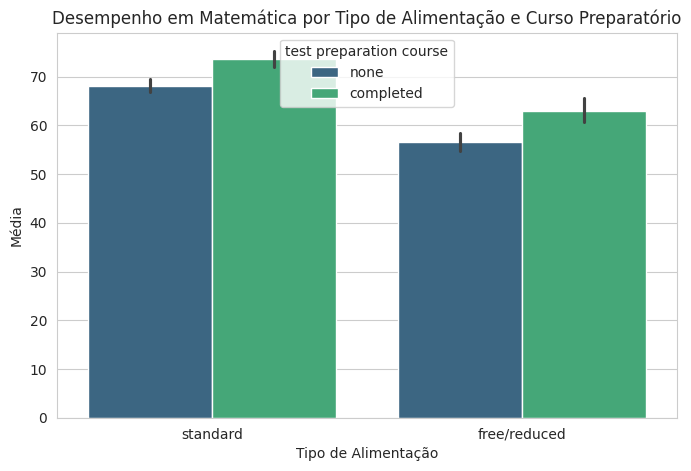

In [ ]:
# cruzamento de dados de nota, almoço e curso

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="lunch",
    y="math score",
    hue="test preparation course",
    palette="viridis"
)

plt.title("Desempenho em Matemática por Tipo de Alimentação e Curso Preparatório")
plt.xlabel("Tipo de Alimentação")
plt.ylabel("Média")

plt.show()

In [ ]:
#h2
df.groupby("gender")[[
    "math score",
    "reading score",
    "writing score",
    ]].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


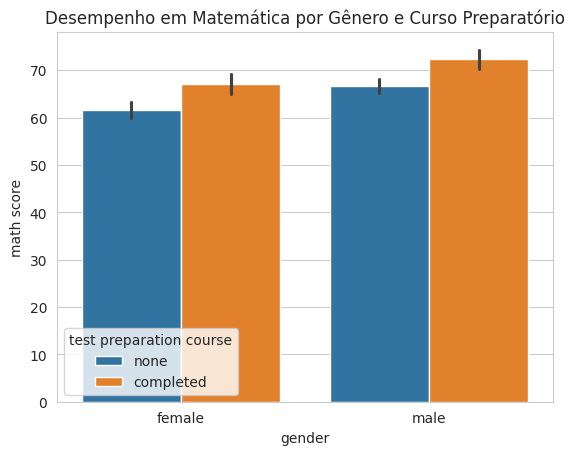

In [ ]:
# nota mat. por genero e curso

sns.barplot(
    data=df,
    x="gender",
    y="math score",
    hue="test preparation course"
)

plt.title("Desempenho em Matemática por Gênero e Curso Preparatório")
plt.show()

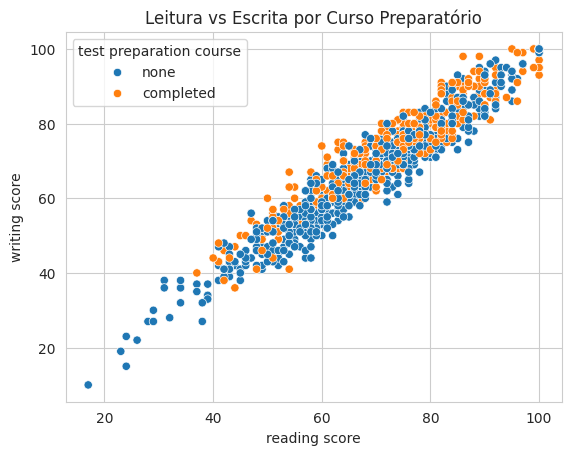

In [ ]:
sns.scatterplot(
    data=df,
    x="reading score",
    y="writing score",
    hue="test preparation course"
)

plt.title("Leitura vs Escrita por Curso Preparatório")
plt.show()

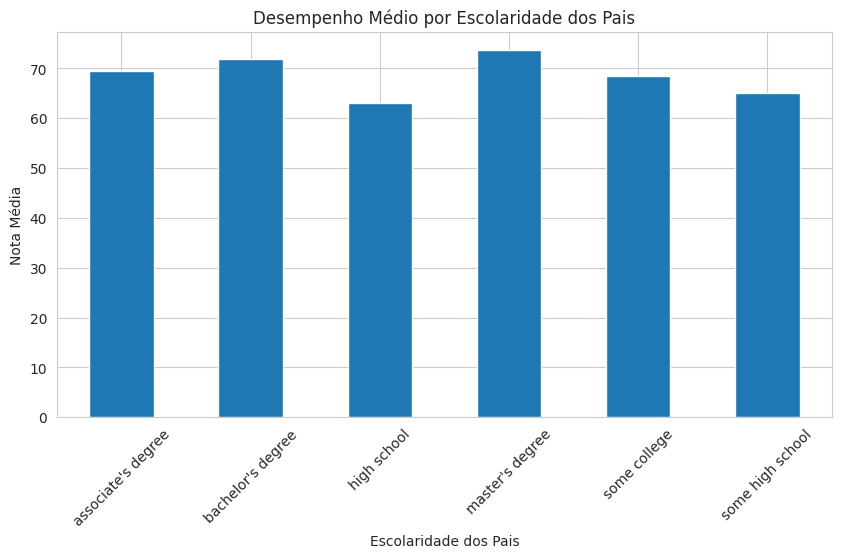

In [355]:
df["mean_score"] = df[[
    "math score",
    "reading score",
    "writing score"
]].mean(axis=1)

df.groupby("parental level of education")["mean_score"].mean().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Desempenho Médio por Escolaridade dos Pais")
plt.xlabel("Escolaridade dos Pais")
plt.ylabel("Nota Média")
plt.xticks(rotation=45)

plt.show()

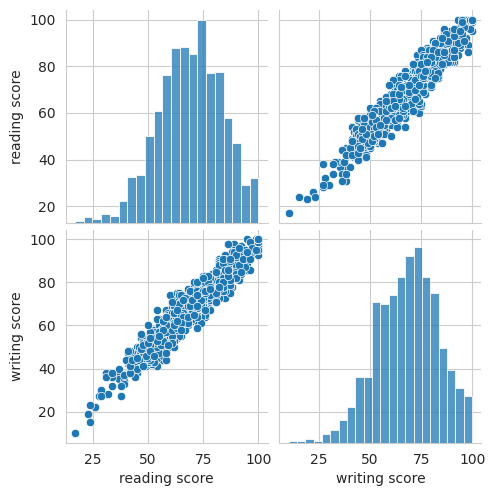

In [ ]:
sns.pairplot(df[[
    "reading score",
    "writing score"
]])


A sequência de visualizações exploratórias permite um melhor conhecimento dos dados, gerando insights a partir do cruzamento de variáveis, contribuindo para uma melhor fundamentação da validação das hipóteses.


#Pré-Processamento de Dados

O Pré-Processamento de Dados tem como objetivo realizar as operações de limpeza de dados, tratamento e preparação dos dados. Essa etapa é essencial para o desenvolvimento de modelos de aprendizado supervisionado, especialmente em problemas de regressão, nos quais o objetivo é prever valores numéricos, a partir de um conjunto de variáveis explicativas.


Em Análise de Dados, foi realizada a verificação da qualidade dos dados, incluindo a análise de valores ausentes e registros duplicados. O conjunto de dados não apresentou valores faltantes nem ocorrências de duplicidade, indicando boa qualidade inicial para as etapas subsequentes de análise.


Em seguida, o conjunto de dados será dividido em variáveis explicativas <b><i>(X)</i></b> e variável alvo<b><i> (y)</i></b>, sendo esta última definida como a nota de matemática <b><i>math score</i></b>, configurando um problema de regressão.


Posteriormente, os dados serão separados em conjuntos de treino e teste, com o objetivo de garantir a avaliação do modelo em dados não vistos e evitar o problema de vazamento de informação.


Após a divisão dos dados, será realizada a transformação das variáveis categóricas em representações numéricas, visto que os algoritmos de regressão trabalham exclusivamente com dados quantitativos. Para as variáveis categóricas binárias, como <b><i>'gender'</i></b> e <i><b>'test preparation course'</b></i>, será aplicada a codificação binária. Já para as variáveis categóricas com múltiplas categorias, como <b><i>'race/ethnicity', 'lunch'</b> <i>e</i><b> 'parental level of education'</i></b>, será empregada a técnica de One-Hot Encoding, permitindo representar cada categoria por meio de variáveis indicadoras.


Além disso, será realizada a etapa de engenharia de atributos, onde novas variáveis derivadas poderão ser criadas a partir das informações originais do Dataset. Entre essas possíveis variáveis, destacam-se métricas agregadas das notas, como médias entre disciplinas e diferenças entre desempenhos específicos, com o objetivo de enriquecer o conjunto de atributos disponíveis para análise e validação das hipóteses.


Por fim, será aplicada a padronização Z-score, baseado na média e no desvio padrão, permitindo comparar variáveis em diferentes escalas. Apesar de não ser sempre obrigatória para todos os modelos, essa etapa poderá contribuir para o desempenho de algoritmos de aprendizado de máquina, especialmente modelos baseados em regressão.





In [ ]:
# valores faltantes zerados
print("Valores nulos por coluna:")
print(df.isnull().sum())


# sem registros duplicados
print("Número de registros duplicados:")
print(df.duplicated().sum())

Valores nulos por coluna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
mean_score                     0
dtype: int64
Número de registros duplicados:
0


Confirmação de ausência de valores faltantes e dados duplicados.

## Variáveis Explicativas (X) e Variável Alvo (y)

In [356]:
# tentar prever nota de mat.

df_antes_split = df.copy()

estilo_df(df_antes_split, "Dados antes da separação em X e y")

display(HTML("<br><br>"))

X = df.drop(columns=["math score"])
y = df["math score"]

estilo_df(X, "Variáveis explicativas (X)")

display(HTML("<br><br>"))

display(HTML("<h3 style='text-align:center;'>Variável alvo (y) - math score</h3>"))

display(
    y.head().to_frame().style
    .set_properties(**{
        "background-color": "#f9f9f9",
        "color": "#333"
    })
    .set_table_styles([
        {"selector": "th",
         "props": [
             ("background-color", "#4CAF50"),
             ("color", "white"),
             ("text-align", "center")
         ]},
        {"selector": "td",
         "props": [("text-align", "center")]}
    ])
)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,mean_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score,mean_score
0,female,group B,bachelor's degree,standard,none,72,74,72.666667
1,female,group C,some college,standard,completed,90,88,82.333333
2,female,group B,master's degree,standard,none,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,57,44,49.333333
4,male,group C,some college,standard,none,78,75,76.333333


,math score
0,72
1,69
2,90
3,47
4,76


Como mencionado, `math score` é a variável alvo (y). Inicialmente, foi criada uma cópia do conjunto de dados para fins de organização e preservação dos dados originais. Em seguida, as variáveis explicativas foram definidas como todos os atributos do conjunto de dados, exceto a variável y, enquanto esta foi definida como variável alvo do modelo.



## Teste e treino

O conjunto de dados será dividido em subconjuntos de treino e teste, utilizando a proporção de 80% e 20%, respectivamente. O objetivo é garantir que o modelo seja treinado em uma parte dos dados e avaliado em dados não vistos.

In [357]:
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

display(HTML("""
<h3 style='text-align:center; margin-bottom:15px;'>
Separação dos dados em treino e teste
</h3>
"""))

# separação dos dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# tabela com tamanhos
import pandas as pd

df_split = pd.DataFrame({
    "Conjunto": ["X_train", "X_test", "y_train", "y_test"],
    "Número de registros": [
        X_train.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_test.shape[0]
    ],
    "Número de variáveis": [
        X_train.shape[1],
        X_test.shape[1],
        1,
        1
    ]
})

display(
    df_split.style
    .set_properties(**{
        "background-color": "#f9f9f9",
        "color": "#333",
        "border-color": "#ccc"
    })
    .set_table_styles([
        {"selector": "th",
         "props": [("background-color", "#4CAF50"),
                   ("color", "white"),
                   ("font-weight", "bold"),
                   ("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "center")]}
    ])
)

,Conjunto,Número de registros,Número de variáveis
0,X_train,800,8
1,X_test,200,8
2,y_train,800,1
3,y_test,200,1


## Variáveis Categóricas Binárias e One-Hot Encoding

In [358]:
# codificacao de gender e course
# melhorar estilizacao


def estilo_df(df, titulo):
    display(HTML(f"""
        <h3 style='text-align:center; margin-bottom:15px;'>
             {titulo}
        </h3>
    """))

    display(
        df.head()
        .style
        .set_properties(**{
            "background-color": "#f9f9f9",
            "color": "#333",
            "border-color": "#ccc"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#4CAF50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center")]}
        ])
        .highlight_max(axis=0, color="#c8e6c9")
    )

estilo_df(df, "Dados antes do pré-processamento")

display(HTML("<br><br><br>"))

df["gender"] = df["gender"].map({
    "female": 0,
    "male": 1
})

df["test preparation course"] = df["test preparation course"].map({
    "none": 0,
    "completed": 1
})

estilo_df(df, "Dados após o pré-processamento")


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,mean_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,mean_score
0,0,group B,bachelor's degree,standard,0,72,72,74,72.666667
1,0,group C,some college,standard,1,69,90,88,82.333333
2,0,group B,master's degree,standard,0,90,95,93,92.666667
3,1,group A,associate's degree,free/reduced,0,47,57,44,49.333333
4,1,group C,some college,standard,0,76,78,75,76.333333


In [359]:
# codificacao de race, lunch e parental educ.
# padronizar estilizacao

def estilo_df(df, titulo):
    display(HTML(f"""
        <h3 style='text-align:center; margin-bottom:15px;'>
             {titulo}
        </h3>
    """))

    display(
        df.head()
        .style
        .set_properties(**{
            "background-color": "#f9f9f9",
            "color": "#333",
            "border-color": "#ccc"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#4CAF50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center")]}
        ])
        .highlight_max(axis=0, color="#c8e6c9")
    )


df_antes_ohe = df.copy()

estilo_df(df_antes_ohe, "Dados antes do One-Hot Encoding")

display(HTML("<br><br><br>"))


df = pd.get_dummies(
    df,
    columns=[
        "race/ethnicity",
        "lunch",
        "parental level of education"
    ],
    drop_first=True,
    dtype=int
)


estilo_df(df, "Dados após o One-Hot Encoding")

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,mean_score
0,0,group B,bachelor's degree,standard,0,72,72,74,72.666667
1,0,group C,some college,standard,1,69,90,88,82.333333
2,0,group B,master's degree,standard,0,90,95,93,92.666667
3,1,group A,associate's degree,free/reduced,0,47,57,44,49.333333
4,1,group C,some college,standard,0,76,78,75,76.333333


,gender,test preparation course,math score,reading score,writing score,mean_score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,72,72,74,72.666667,1,0,0,0,1,1,0,0,0,0
1,0,1,69,90,88,82.333333,0,1,0,0,1,0,0,0,1,0
2,0,0,90,95,93,92.666667,1,0,0,0,1,0,0,1,0,0
3,1,0,47,57,44,49.333333,0,0,0,0,0,0,0,0,0,0
4,1,0,76,78,75,76.333333,0,1,0,0,1,0,0,0,1,0


##Engenharia de Atributos

In [360]:
# calculo de media total das nots - (deu mat. pensar na escrita do resultado)
# padrao das variaveis categ.

def estilo_df(df, titulo, destacar_coluna=None):
    display(HTML(f"""
        <h3 style='text-align:center; margin-bottom:15px;'>
             {titulo}
        </h3>
    """))

    estilo = (
        df.head()
        .style
        .set_properties(**{
            "background-color": "#f9f9f9",
            "color": "#333",
            "border-color": "#ccc"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#4CAF50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center")]}
        ])
    )

    if destacar_coluna:
        estilo = estilo.highlight_max(subset=[destacar_coluna], color="#ffe082")

    display(estilo)

df_before = df.copy()

df_before = df_before.drop(columns=["mean_score"], errors="ignore")

estilo_df(df_before, "Antes da criação da variável mean_score")

display(HTML("<br><br><br>"))

df_after = df.copy()

df_after["mean_score"] = df_after[
    ["math score", "reading score", "writing score"]
].mean(axis=1)

estilo_df(df_after, "Após a criação da variável mean_score", destacar_coluna="mean_score")

,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,72,72,74,1,0,0,0,1,1,0,0,0,0
1,0,1,69,90,88,0,1,0,0,1,0,0,0,1,0
2,0,0,90,95,93,1,0,0,0,1,0,0,1,0,0
3,1,0,47,57,44,0,0,0,0,0,0,0,0,0,0
4,1,0,76,78,75,0,1,0,0,1,0,0,0,1,0


,gender,test preparation course,math score,reading score,writing score,mean_score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,72,72,74,72.666667,1,0,0,0,1,1,0,0,0,0
1,0,1,69,90,88,82.333333,0,1,0,0,1,0,0,0,1,0
2,0,0,90,95,93,92.666667,1,0,0,0,1,0,0,1,0,0
3,1,0,47,57,44,49.333333,0,0,0,0,0,0,0,0,0,0
4,1,0,76,78,75,76.333333,0,1,0,0,1,0,0,0,1,0


In [361]:
# diferenca entre mat. leitura e escrita

def estilo_df(df, titulo, destacar_colunas=None):
    display(HTML(f"""
        <h3 style='text-align:center; margin-bottom:15px;'>
             {titulo}
        </h3>
    """))

    estilo = (
        df.head()
        .style
        .set_properties(**{
            "background-color": "#f9f9f9",
            "color": "#333",
            "border-color": "#ccc"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#4CAF50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center")]}
        ])
    )

    if destacar_colunas:
        estilo = estilo.highlight_max(subset=destacar_colunas, color="#ffe082")

    display(estilo)

df_antes_diff = df.copy()

estilo_df(df_antes_diff, "Antes da criação das variáveis de diferença")

display(HTML("<br><br><br>"))


df_depois_diff = df.copy()

df_depois_diff["math_vs_reading"] = df_depois_diff["math score"] - df_depois_diff["reading score"]
df_depois_diff["math_vs_writing"] = df_depois_diff["math score"] - df_depois_diff["writing score"]

estilo_df(
    df_depois_diff,
    "Após a criação das variáveis math_vs_reading e math_vs_writing",
    destacar_colunas=["math_vs_reading", "math_vs_writing"]
)

,gender,test preparation course,math score,reading score,writing score,mean_score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,72,72,74,72.666667,1,0,0,0,1,1,0,0,0,0
1,0,1,69,90,88,82.333333,0,1,0,0,1,0,0,0,1,0
2,0,0,90,95,93,92.666667,1,0,0,0,1,0,0,1,0,0
3,1,0,47,57,44,49.333333,0,0,0,0,0,0,0,0,0,0
4,1,0,76,78,75,76.333333,0,1,0,0,1,0,0,0,1,0


,gender,test preparation course,math score,reading score,writing score,mean_score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,math_vs_reading,math_vs_writing
0,0,0,72,72,74,72.666667,1,0,0,0,1,1,0,0,0,0,0,-2
1,0,1,69,90,88,82.333333,0,1,0,0,1,0,0,0,1,0,-21,-19
2,0,0,90,95,93,92.666667,1,0,0,0,1,0,0,1,0,0,-5,-3
3,1,0,47,57,44,49.333333,0,0,0,0,0,0,0,0,0,0,-10,3
4,1,0,76,78,75,76.333333,0,1,0,0,1,0,0,0,1,0,-2,1


In [362]:
# relacao com o curso

df_antes_prep = df.copy()

estilo_df(df_antes_prep, "Antes da criação da variável prep_effect_math")

display(HTML("<br><br><br>"))

df["prep_effect_math"] = df["test preparation course"] * df["math score"]

estilo_df(
    df,
    "Após a criação da variável prep_effect_math",
    destacar_colunas=["prep_effect_math"]
)

,gender,test preparation course,math score,reading score,writing score,mean_score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,72,72,74,72.666667,1,0,0,0,1,1,0,0,0,0
1,0,1,69,90,88,82.333333,0,1,0,0,1,0,0,0,1,0
2,0,0,90,95,93,92.666667,1,0,0,0,1,0,0,1,0,0
3,1,0,47,57,44,49.333333,0,0,0,0,0,0,0,0,0,0
4,1,0,76,78,75,76.333333,0,1,0,0,1,0,0,0,1,0


,gender,test preparation course,math score,reading score,writing score,mean_score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,prep_effect_math
0,0,0,72,72,74,72.666667,1,0,0,0,1,1,0,0,0,0,0
1,0,1,69,90,88,82.333333,0,1,0,0,1,0,0,0,1,0,69
2,0,0,90,95,93,92.666667,1,0,0,0,1,0,0,1,0,0,0
3,1,0,47,57,44,49.333333,0,0,0,0,0,0,0,0,0,0,0
4,1,0,76,78,75,76.333333,0,1,0,0,1,0,0,0,1,0,0


In [363]:
# relacao com genero

df_antes_gender = df.copy()

estilo_df(df_antes_gender, "Antes da criação da variável gender_math_interaction")

display(HTML("<br><br><br>"))

df["gender_math_interaction"] = df["gender"] * df["math score"]

estilo_df(
    df,
    "Após a criação da variável gender_math_interaction",
    destacar_colunas=["gender_math_interaction"]
)

,gender,test preparation course,math score,reading score,writing score,mean_score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,prep_effect_math
0,0,0,72,72,74,72.666667,1,0,0,0,1,1,0,0,0,0,0
1,0,1,69,90,88,82.333333,0,1,0,0,1,0,0,0,1,0,69
2,0,0,90,95,93,92.666667,1,0,0,0,1,0,0,1,0,0,0
3,1,0,47,57,44,49.333333,0,0,0,0,0,0,0,0,0,0,0
4,1,0,76,78,75,76.333333,0,1,0,0,1,0,0,0,1,0,0


,gender,test preparation course,math score,reading score,writing score,mean_score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,prep_effect_math,gender_math_interaction
0,0,0,72,72,74,72.666667,1,0,0,0,1,1,0,0,0,0,0,0
1,0,1,69,90,88,82.333333,0,1,0,0,1,0,0,0,1,0,69,0
2,0,0,90,95,93,92.666667,1,0,0,0,1,0,0,1,0,0,0,0
3,1,0,47,57,44,49.333333,0,0,0,0,0,0,0,0,0,0,0,47
4,1,0,76,78,75,76.333333,0,1,0,0,1,0,0,0,1,0,0,76


## Transformações Numéricas

In [364]:
# criando variaveis de log e +1 log de zero
df["math_log"] = np.log(df["math score"] + 1)

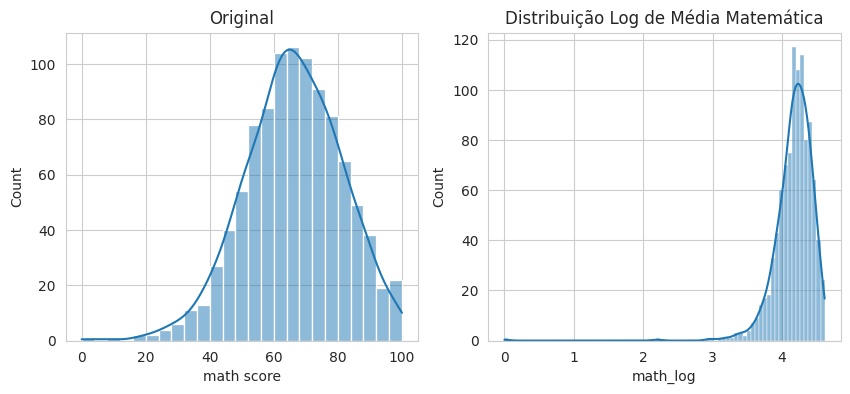

In [365]:
# usando a tecnica de transformacao logarítmica
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df["math score"], kde=True, ax=axes[0])
axes[0].set_title("Original")

sns.histplot(df["math_log"], kde=True, ax=axes[1])
axes[1].set_title("Distribuição Log de Média Matemática")

plt.show()

A transformação logarítmica é uma técnica necessária para reduzir a assimetria em distribuições numéricas.
No entanto, para esse Dataset, essa técnica não se mostra essencial, uma vez que as notas estão distribuídas em uma escala de 0 a 100.0. Apenas para fins didáticos e de aprendizado, a técnica foi explorada na variável de matemática, por ser a que apresenta leve dispersão em comparação às demais.



## Padronização dos Dados

In [367]:

from sklearn.preprocessing import StandardScaler
import pandas as pd
from IPython.display import display, HTML


numerical_cols = [
    "reading score",
    "writing score",
    "mean_score"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


display(HTML("""
<h3 style='text-align:center; font-weight:bold; margin-bottom:10px;'>
    Dados Padronizados de Treino
</h3>
"""))

display(
    X_train_scaled.head(3).style.set_properties(**{
        "background-color": "#f9f9f9",
        "color": "#333",
        "text-align": "center"
    }).set_table_styles([
        {"selector": "th",
         "props": [("background-color", "#4CAF50"),
                   ("color", "white"),
                   ("font-weight", "bold"),
                   ("text-align", "center")]}
    ])
)


display(HTML("<br><br>"))


display(HTML("""
<h3 style='text-align:center; font-weight:bold; margin-bottom:10px;'>
    Dados Padronizados de Teste
</h3>
"""))

display(
    X_test_scaled.head(3).style.set_properties(**{
        "background-color": "#f9f9f9",
        "color": "#333",
        "text-align": "center"
    }).set_table_styles([
        {"selector": "th",
         "props": [("background-color", "#4CAF50"),
                   ("color", "white"),
                   ("font-weight", "bold"),
                   ("text-align", "center")]}
    ])
)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score,mean_score
29,female,group D,master's degree,standard,none,0.030791,0.434053,0.058830
535,female,group C,bachelor's degree,free/reduced,completed,0.930290,0.964701,0.648898
695,female,group D,some college,free/reduced,none,1.345443,1.163694,1.168158


,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score,mean_score
521,female,group C,associate's degree,standard,none,1.137866,1.031032,1.333378
737,female,group B,some college,free/reduced,completed,-0.245978,0.301391,-0.295211
740,male,group D,bachelor's degree,standard,none,0.238367,0.235060,0.483679


# Respondendo as Hipóteses


<b>Hipótese 1 - <i> Estudantes que realizaram curso preparatório tendem a apresentar melhores notas.</i></b>
<br><br>

Sim. Os estudantes que concluíram o curso obtiveram 69,69 pontos em matemática, 73,89 em leitura e 74,41 em escrita. Em contrapartida, aqueles que não participaram do curso apresentaram médias de 64,07 em matemática, 66,53 em leitura e 64,50 em escrita. A diferença positiva para o grupo que realizou o curso é de: 5.62 em matemática, 7.36 em leitura e 9.91. Esses resultados evidenciam que a realização de um curso preparatório está associada a um melhor desempenho acadêmico.
<br><br>
<b>Hipótese 2 - <i>Existe diferença de desempenho entre estudantes do sexo masculino e feminino.</i></b>
<br><br>

Sim. A média geral de todas as disciplinas apresenta 69.56 para o sexo feminino e 65.83 para o sexo masculino. Entretando, ao avaliar as médias das disciplinas separadamente, estudantes do sexo masculino apresentam melhor desempenho em matemática. Por outro lado, estudantes do sexo feminino apresentam médias maiores em leitura e escrita, com isso, elevam o desempenho médio geral.
<br><br>

<b>Hipótese 3 - <i>Fatores demográficos e sociais podem evidenciar algum tipo de desigualdade no desempenho acadêmico. </b></i>
<br><br>
Para a validação dessa hipótese, faz-se necessário uma análise particionada. Inicialmente, observa-se a relação entre raça/etnia e o desempenho nas disciplinas. Considerando a variável `race/ethnicity`, o <b>grupo A</b> apresenta as seguintes médias: matemática 61,63, leitura 64,67 e escrita 62,67. Já o <b>grupo E</b> apresenta médias de matemática 73,82, leitura 73,03 e escrita 71,41. Existe uma clara diferença de desempenho entre os grupos, o que sugere que características demográficas podem ter alguma interferência em desempenho acadêmico.

A análise sob a ótica da variável `lunch` traz um indicativo interessante. Estudantes que recebem almoço reduzido, associado a condição socioeconômica inferior, apresentam desempenho médio inferior em todas as disciplinas quando comparados aos estudantes com melhor condição socioeconômica, consequentemente um almoço padrão.

No aspecto relacionado à variável parental level of education, um resultado 'óbvio': quanto maior o nível de escolaridade dos pais, maiores são as médias obtidas pelos estudantes nas disciplinas. O resultado reforça o que aponta nos estudos da área de educação, o ambiente familiar e o nível escolar dos pais influenciam no desempenho acadêmico dos filhos.

Entre todos os fatores analisados, o tipo de almoço parece ser o indicador mais forte de desigualdade, pois apresenta as maiores diferença nas médias entre os grupo `race/ethnicity`.<i> <br><br>
Sob uma perspectiva pessoal, esse resultado trouxe uma pausa reflexiva: o desempenho acadêmico pode ser comprometido por elementos ligados à desigualdade social e, por trás desses números, existem pessoas com realidades e oportunidades muito distintas.</i>
<br><br>

<b>Hipótese 4-  <i>Existe alguma correlação entre as notas de leitura e escrita.</i></b>
<br><br>
Sim. Estudantes com melhor desempenho em leitura tendem a apresentar também melhor desempenho em escrita. A Matriz de Correlação apresentou valor próximo de +1 entre as variáveis <b><i>Reading Score</i></b> e <i><b>Writing Score</i></b>, indicando uma forte correlação positiva. Além disso, o gráfico de dispersão entre essas variáveis, apresentado na seção <i>'Exploração Adicional'</i>, também reafirma esse comportamento, demonstrando um padrão linear crescente.
<br><br>
<b>Hipótese 5 - <i>As notas de matemática apresentam maior variabilidade, indicando maior dispersão dos resultados em relação às disciplinas de leitura e escrita.</i></b>
<br><br>
Para essa validação, deve-se observar o desvio padrão, que indica a variabilidade em matemática é maior em relação às demais disciplinas. Esse comportamento se confirma por meio do gráfico Boxplot, onde as notas de matemática apresentam maior dispersão de valores.




# Conclusão

Esse projeto analisou o desempenho acadêmico dos estudantes com base em variáveis demográficas, sociais e educacionais, utilizando técnicas de análise exploratória de dados e pré-processamento. O conjunto de dados contém informações sobre notas em matemática, leitura e escrita, além de variáveis como gênero, raça/etnia, nível de escolaridade dos pais, tipo de almoço e participação em curso preparatório.

Os resultados das análises por grupo evidenciaram padrões entre as variáveis. Em relação à raça/etnia, observou-se diferença de desempenho entre os grupos, com destaque para maiores médias no <b>grupo E</b> e menores no <b>grupo A</b>. Quanto ao tipo de almoço, estudantes com alimentação padrão apresentaram desempenho superior aos que recebem alimentação gratuita ou reduzida, sugerindo influência de fatores socioeconômicos. Esse resultado indica que essa variável pode representar um dos principais fatores associados às diferenças de desempenho observadas no conjunto de dados.

Ao analisar a escolaridade dos pais, identificou-se uma tendência positiva entre nível educacional e desempenho acadêmico. Estudantes com pais que possuem maior grau de escolaridade tendem a apresentar melhores resultados. Já a participação em curso preparatório também demonstrou associação positiva com o desempenho, especialmente nas disciplinas de leitura e escrita.

No decorrer dos testes das hipóteses, abriria a possibilidade de investigar mais duas hipóteses adicionais, como:
- <b><i>O nível de escolaridade dos pais pode ter maior impacto no desempenho em matemática do que nas demais disciplinas.</i> </b><br><br>
- <b><i>Estudantes que realizam curso preparatório podem apresentar menor variação nas notas, indicando maior consistência de desempenho.</b></i>

Essas relações poderiam ser analisadas por meio da comparação de médias por disciplina e da avaliação da dispersão das notas entre os grupos.

De forma geral, os resultados indicam que fatores sociais, econômicos e educacionais estão associados ao desempenho acadêmico dos estudantes, evidenciando padrões consistentes de desigualdade entre os grupos analisados. A conclusão do estudo reforça a influência do contexto social no desempenho escolar.

Por fim, as visualizações e análises exploratórias foram essenciais para a identificação desses padrões, permitindo uma compreensão clara e estruturada do comportamento dos dados.
